In [1]:
# IMPORT ALL PROJECT MODULES

from ball_observation import BallObservation
from ball_trajectory import Ball, simulate_n_balls
from particle_filter import ParticleFilter
from nball_particle_filter import NBallParticleFilter
import importlib
import plotting
importlib.reload(plotting)

from plotting import (
    BallTrajectoryPlot,
    BallObservationPlot,
    ParticleFilterTrajectoryPlot,
    ParticleEvolutionAnimation,
    nBallTrajectoryPlot
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


ImportError: cannot import name 'nBallTrajectoryPlot' from 'plotting' (d:\STUDIES\MASTERS\SEM 1\Reasoning and Decision Making under Uncertainty\PORTFOLIO2\ball-tracking-particle-filter\src\plotting.py)


TIME STEP|| TRAJECTORY(x,y)1:
------------------------------
t= 0.00s || (  0.00,   0.00)
t= 0.10s || (  3.54,   3.44)
t= 0.20s || (  7.07,   6.78)
t= 0.30s || ( 10.61,  10.02)
t= 0.40s || ( 14.14,  13.16)
t= 0.50s || ( 17.68,  16.21)
t= 0.60s || ( 21.21,  19.15)
t= 0.70s || ( 24.75,  22.00)
t= 0.80s || ( 28.28,  24.75)
t= 0.90s || ( 31.82,  27.41)
t= 1.00s || ( 35.36,  29.96)
t= 1.10s || ( 38.89,  32.42)
t= 1.20s || ( 42.43,  34.77)
t= 1.30s || ( 45.96,  37.03)
t= 1.40s || ( 49.50,  39.20)
t= 1.50s || ( 53.03,  41.26)
t= 1.60s || ( 56.57,  43.23)
t= 1.70s || ( 60.10,  45.09)
t= 1.80s || ( 63.64,  46.86)
t= 1.90s || ( 67.18,  48.54)
t= 2.00s || ( 70.71,  50.11)
t= 2.10s || ( 74.25,  51.59)
t= 2.20s || ( 77.78,  52.96)
t= 2.30s || ( 81.32,  54.24)
t= 2.40s || ( 84.85,  55.42)
t= 2.50s || ( 88.39,  56.51)
t= 2.60s || ( 91.92,  57.49)
t= 2.70s || ( 95.46,  58.38)
t= 2.80s || ( 98.99,  59.17)
t= 2.90s || (102.53,  59.86)
t= 3.00s || (106.07,  60.45)
t= 3.10s || (109.60,  60.94)
t= 3.20s |

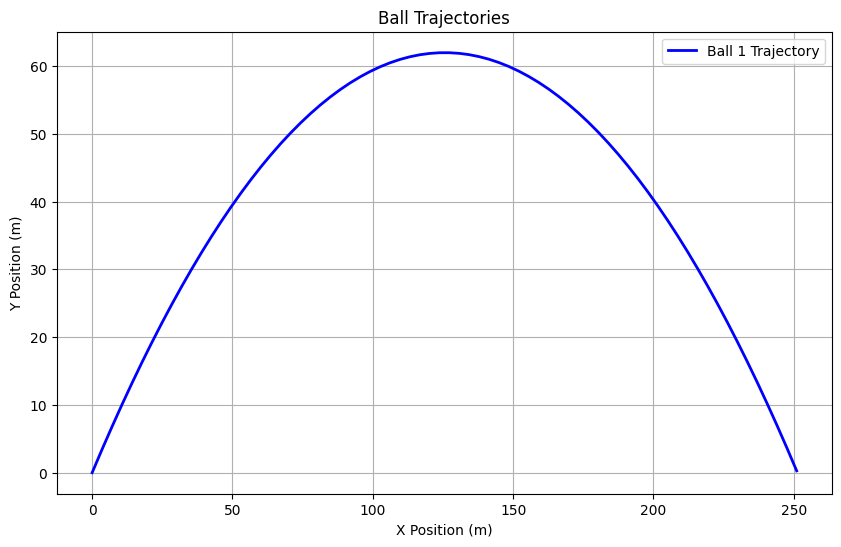

In [ ]:
#Balltrajectory
launches = [
    {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45}
]

# Simulate trajectories
trajectories = simulate_n_balls(launches, dt=0.1)

# Print formatted trajectory output

for i, traj in enumerate(trajectories):
    print(f"\nTIME STEP|| TRAJECTORY(x,y){i+1}:")
    print("------------------------------")
    for t, x, y in traj:
        print(f"t={t:5.2f}s || ({x:6.2f}, {y:6.2f})")

# Visualize trajectory
plotter = BallTrajectoryPlot(launches)
plotter.visualize()

TIME STEP || BALL 1 ||
           || Obs. (x,y) ||
---------------------------------------------------------------

Ball 1:
t= 0.00s || Observation Dropped
t= 0.10s || Observation Dropped
t= 0.20s || (  7.14,   5.09)
t= 0.30s || ( 15.00,  10.67)
t= 0.40s || ( 13.61,  11.66)
t= 0.50s || ( 20.84,  16.08)
t= 0.60s || ( 17.96,  17.39)
t= 0.70s || Observation Dropped
t= 0.80s || ( 27.90,  27.07)
t= 0.90s || ( 33.55,  29.12)
t= 1.00s || ( 34.09,  26.40)
t= 1.10s || ( 40.27,  37.44)
t= 1.20s || ( 44.03,  38.25)
t= 1.30s || ( 43.49,  37.81)
t= 1.40s || ( 49.54,  42.51)
t= 1.50s || ( 51.97,  37.81)
t= 1.60s || ( 54.47,  43.79)
t= 1.70s || ( 59.12,  50.32)
t= 1.80s || ( 63.10,  42.74)
t= 1.90s || ( 71.38,  46.28)
t= 2.00s || ( 73.28,  41.76)
t= 2.10s || ( 76.53,  53.60)
t= 2.20s || ( 77.89,  54.19)
t= 2.30s || ( 80.06,  54.92)
t= 2.40s || ( 85.00,  49.89)
t= 2.50s || ( 85.78,  55.64)
t= 2.60s || ( 89.14,  61.33)
t= 2.70s || ( 91.55,  54.69)
t= 2.80s || Observation Dropped
t= 2.90s || Observation

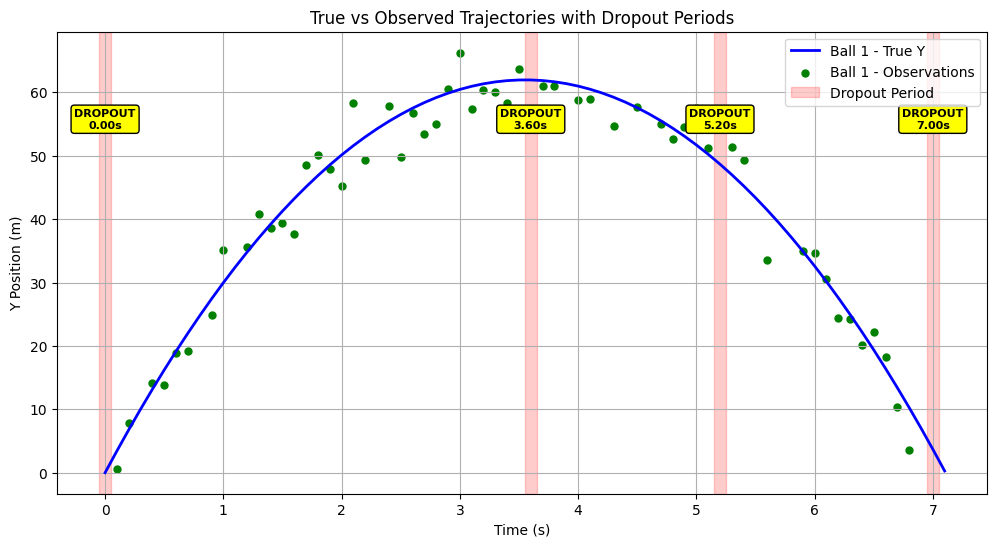

In [ ]:
#BallObservation

launches = [
        {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45}
    ]

trajectories      = simulate_n_balls(launches, dt=0.1)

observers = [
                BallObservation(traj, noise_stddev=3.0, dropout_prob=0.2)
                for traj in trajectories
                ]
print("===============================================================")
print("TIME STEP || BALL 1 ||")
print("           || Obs. (x,y) ||")
print("---------------------------------------------------------------")

for i, obs in enumerate(observers):
    print(f"\nBall {i + 1}:")
    observations = obs.simulate_observations()
    for t, position in observations:
        if position is not None:
            print(f"t={t:5.2f}s || ({position[0]:6.2f}, {position[1]:6.2f})")
        else:
            print(f"t={t:5.2f}s || Observation Dropped")
    
plotter = BallObservationPlot(trajectories, noise_stddev=3.0, dropout_prob=0.2)
plotter.visualize()

TIME STEP||      Obs.      |       Est.     ||
t= 0.00s || ( 10.4,   9.1) | ( 10.3,  10.9) ||
t= 0.10s || ( 31.5,  18.1) | ( 20.9,  15.1) ||
t= 0.20s || ( 22.9,  25.4) | ( 22.2,  19.3) ||
t= 0.30s || ( 18.6,  14.3) | ( 21.7,  19.4) ||
t= 0.40s || ( 26.6,  28.2) | ( 23.7,  22.3) ||
t= 0.50s ||     Dropout    | ( 24.9,  23.7) ||
t= 0.60s ||     Dropout    | ( 26.1,  25.0) ||
t= 0.70s || ( 44.9,  25.5) | ( 40.1,  25.6) ||
t= 0.80s || ( 41.4,  37.0) | ( 42.0,  30.6) ||
t= 0.90s ||     Dropout    | ( 45.5,  31.9) ||
t= 1.00s || ( 51.2,  53.0) | ( 47.9,  40.1) ||
t= 1.10s || ( 57.0,  60.6) | ( 52.0,  48.4) ||
t= 1.20s || ( 45.4,  59.4) | ( 50.6,  58.3) ||
t= 1.30s || ( 57.9,  60.6) | ( 53.7,  62.6) ||
t= 1.40s ||     Dropout    | ( 56.8,  66.3) ||
t= 1.50s || ( 80.7,  40.3) | ( 70.2,  52.6) ||
t= 1.60s ||     Dropout    | ( 74.2,  53.8) ||
t= 1.70s || ( 66.9,  57.8) | ( 75.8,  54.3) ||
t= 1.80s ||     Dropout    | ( 79.6,  55.4) ||
t= 1.90s ||     Dropout    | ( 83.4,  56.4) ||
t= 2.00s || (

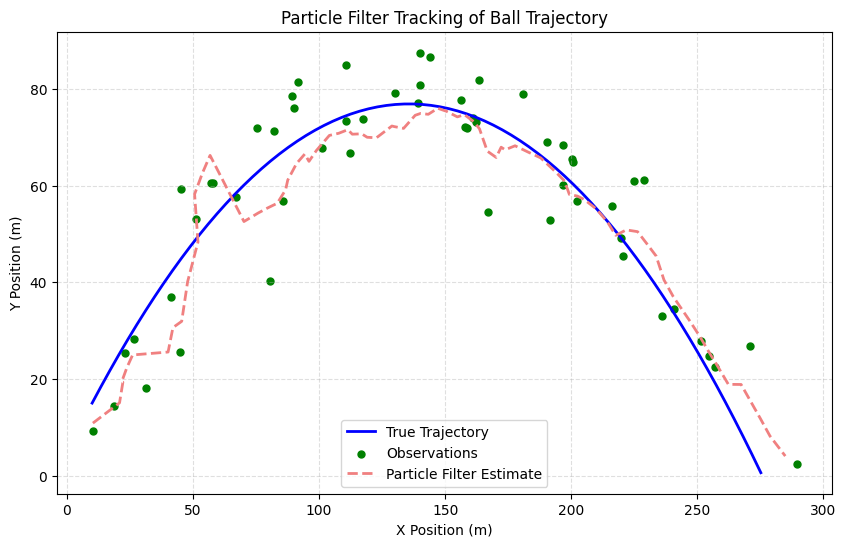

In [12]:
if __name__ == "__main__":
    launches = [
        {"initial_position": [10, 15], "speed": 50, "angle_degrees": 45}
    ]

    trajectories = simulate_n_balls(launches, dt=0.1)
    noise_stddev = 8.0
    observers = [
        BallObservation(traj, noise_stddev=noise_stddev, dropout_prob=0.2)
        for traj in trajectories
    ]

    observations_ball0 = observers[0].simulate_observations()

    # Single filter run — estimates used for both printing and plotting
    pf = ParticleFilter(num_particles=1000, noise_stddev=noise_stddev, area=100.0, noise=1.0)
    estimates = []
    print("============================================")
    print("TIME STEP||      Obs.      |       Est.     ||")
    print("============================================")

    for t, obs in observations_ball0:
        estimate = pf.step(dt=0.1, observation=obs)
        estimates.append(estimate)

        if obs is None:
            obs_str = "    Dropout   "
        else:
          obs_str = f"({obs[0]:5.1f}, {obs[1]:5.1f})"

        est_str = f"({estimate[0]:5.1f}, {estimate[1]:5.1f})"
        print(f"t={t:5.2f}s || {obs_str} | {est_str} ||")

    plotter = ParticleFilterTrajectoryPlot(
        trajectory=trajectories[0],
        observations=observations_ball0,
        estimates=estimates
    )
    plotter.visualize()


Initializing 5000 particles for 3 balls in area 100.0x100.0
TIME STEP ||             BALL 0              ||             BALL 1              ||             BALL 2              ||
          ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||
---------------------------------------------------------------------------------------------------------------------
t= 0.00s  ||(  -4.2,   5.2) | (  -2.2,   8.1)||      N/A       | (  21.8,   3.9)||(  22.3,   0.5) | (  -6.0,  25.7)||
t= 0.10s  ||(   9.0,   6.1) | (   3.2,  14.2)||(   9.5,   2.8) | (  24.9,   3.8)||(  22.4,   0.5) | (   1.3,  15.1)||
t= 0.20s  ||(   9.2,  12.9) | (  16.0,  16.4)||(  19.4,  13.8) | (  11.9,  18.4)||(  26.9,   7.5) | (  28.5,   4.8)||
t= 0.30s  ||(  13.2,  11.2) | (  19.8,  15.3)||(  13.1,   7.8) | (  16.9,  17.9)||(  26.6,  12.7) | (  11.3,  21.6)||
t= 0.40s  ||(  23.9,  16.3) | (  24.5,  16.8)||(  19.3,   3.3) | (  15.5,  25.5)||(  34.7,  16.2) | (  29.6,  20.4

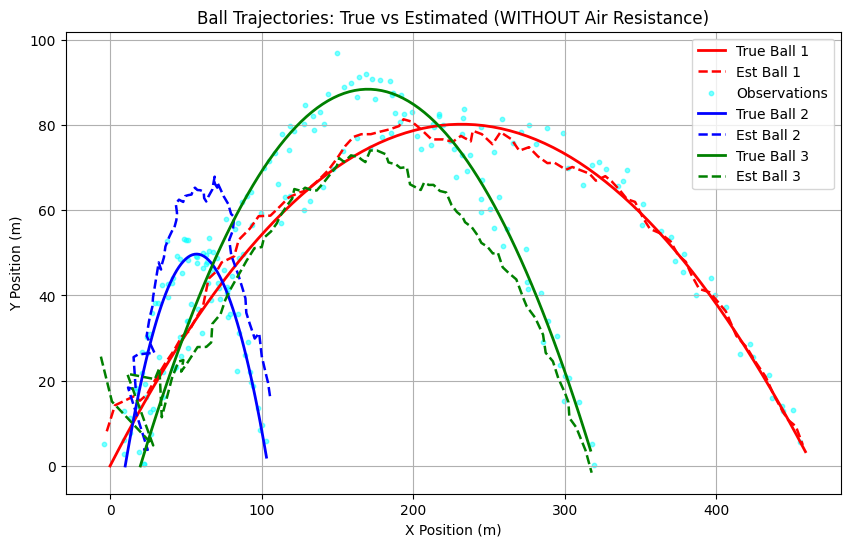

In [ ]:
def assign_estimates(est: np.ndarray, true_positions: list) -> np.ndarray:
    
    assigned = np.empty_like(est)
    used = set()
    for b, tp in enumerate(true_positions):
        tp   = np.array(tp)
        best = min((j for j in range(len(est)) if j not in used),
                    key=lambda j: np.linalg.norm(est[j, :2] - tp))
        assigned[b] = est[best]
        used.add(best)
    return assigned
SAMPLE_SETS = {
        1: [  # Different angles, wide separation 
            {"initial_position": [0,  0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [20, 0], "speed": 60, "angle_degrees": 30},
        ],
        2: [  # Steep vs shallow 
            {"initial_position": [0,  0], "speed": 55, "angle_degrees": 75},
            {"initial_position": [15, 0], "speed": 45, "angle_degrees": 25},
        ],
        3: [  # Similar speeds and angles 
            {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [5, 0], "speed": 52, "angle_degrees": 47},
        ],
        4: [  # Fast vs slow, different heights
            {"initial_position": [0,  0], "speed": 70, "angle_degrees": 35},
            {"initial_position": [10, 0], "speed": 35, "angle_degrees": 65},
            {"initial_position": [20, 0], "speed": 55, "angle_degrees": 50},
        ],
    }

SAMPLE = 4      
launches = SAMPLE_SETS[SAMPLE]

DT           = 0.1
N_BALLS      = len(launches)
NOISE_STDDEV = 3.0
DROPOUT_PROB = 0.02
trajectories = simulate_n_balls(launches, dt=DT)
observers     = [BallObservation(traj, noise_stddev=NOISE_STDDEV, dropout_prob=DROPOUT_PROB)
                     for traj in trajectories]
obs_sequences = [obs.simulate_observations() for obs in observers]

pf = NBallParticleFilter(num_particles=5000, n_balls=N_BALLS, noise_stddev=NOISE_STDDEV, area=100.0, noise=NOISE_STDDEV/2)

estimated_trajectories = {i: [] for i in range(N_BALLS)}

# Use longest sequence so no ball is cut short
n_steps = max(len(seq) for seq in obs_sequences)

_cw = 15  # width of each obs/est value cell
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'TIME STEP':^10}||" + "".join(f"{'BALL '+str(b):^{_cw*2+3}}||" for b in range(N_BALLS)))
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'':10}||" + "".join(f"{'Obs.':^{_cw}} | {'Est.':^{_cw}}||" for b in range(N_BALLS)))
print("-" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))

fmt = lambda v: f"({v[0]:6.1f},{v[1]:6.1f})" if v is not None else f"{'N/A':^{_cw}}"

for step_idx in range(n_steps):
        t        = next(obs_sequences[b][step_idx][0] for b in range(N_BALLS) if step_idx < len(obs_sequences[b]))
        obs_list = [obs_sequences[b][step_idx][1] if step_idx < len(obs_sequences[b]) else None for b in range(N_BALLS)]
        true_pos = [trajectories[b][min(step_idx, len(trajectories[b])-1)][1:3] for b in range(N_BALLS)]
        est      = assign_estimates(pf.step(dt=DT, observations=obs_list), true_pos)

        for b in range(N_BALLS):
            if step_idx < len(trajectories[b]):
                estimated_trajectories[b].append(est[b])

        print(f"t={t:5.2f}s  ||" + "".join(
            f"{fmt(obs_list[b])} | {fmt(est[b, :2] if step_idx < len(trajectories[b]) else None)}||"
            for b in range(N_BALLS)))


nBallTrajectoryPlot(
    trajectories=trajectories,
    observations=obs_sequences,
    estimates=[estimated_trajectories[i] for i in range(N_BALLS)]
).visualize()

